Instalando dependencias necesarias...
Iniciando motor de eventos discretos...
Simulación finalizada de manera exitosa.

             CENTRO COMERCIAL SUPERCENTRO - RESULTADOS

[PUNTO A: ESTADÍSTICAS OPERATIVAS DE ATENCIÓN POR CAJERO]
Cajero 1 -> Media Atención: 3.38 min | IC 95%: [3.02, 3.75] | Máx Servicio: 34.50 min
Cajero 2 -> Media Atención: 3.47 min | IC 95%: [3.08, 3.86] | Máx Servicio: 36.46 min
Cajero 3 -> Media Atención: 3.52 min | IC 95%: [3.15, 3.89] | Máx Servicio: 34.16 min
------------------------------------------------------------
➔ Cajero con MENOR tiempo promedio de atención: Cajero 1 (3.38 min)
➔ Cajero con MAYOR tiempo promedio de atención: Cajero 3 (3.52 min)
------------------------------------------------------------

[PUNTO B: CANTIDAD Y PROPORCIÓN DE USUARIOS POR TIPO]
 - Rapido    : 454 usuarios (26.44%) | Esperado: 25.00%
 - Normal    : 318 usuarios (18.52%) | Esperado: 20.00%
 - Lento     : 476 usuarios (27.72%) | Esperado: 27.50%
 - Muy Lento : 469 usuarios

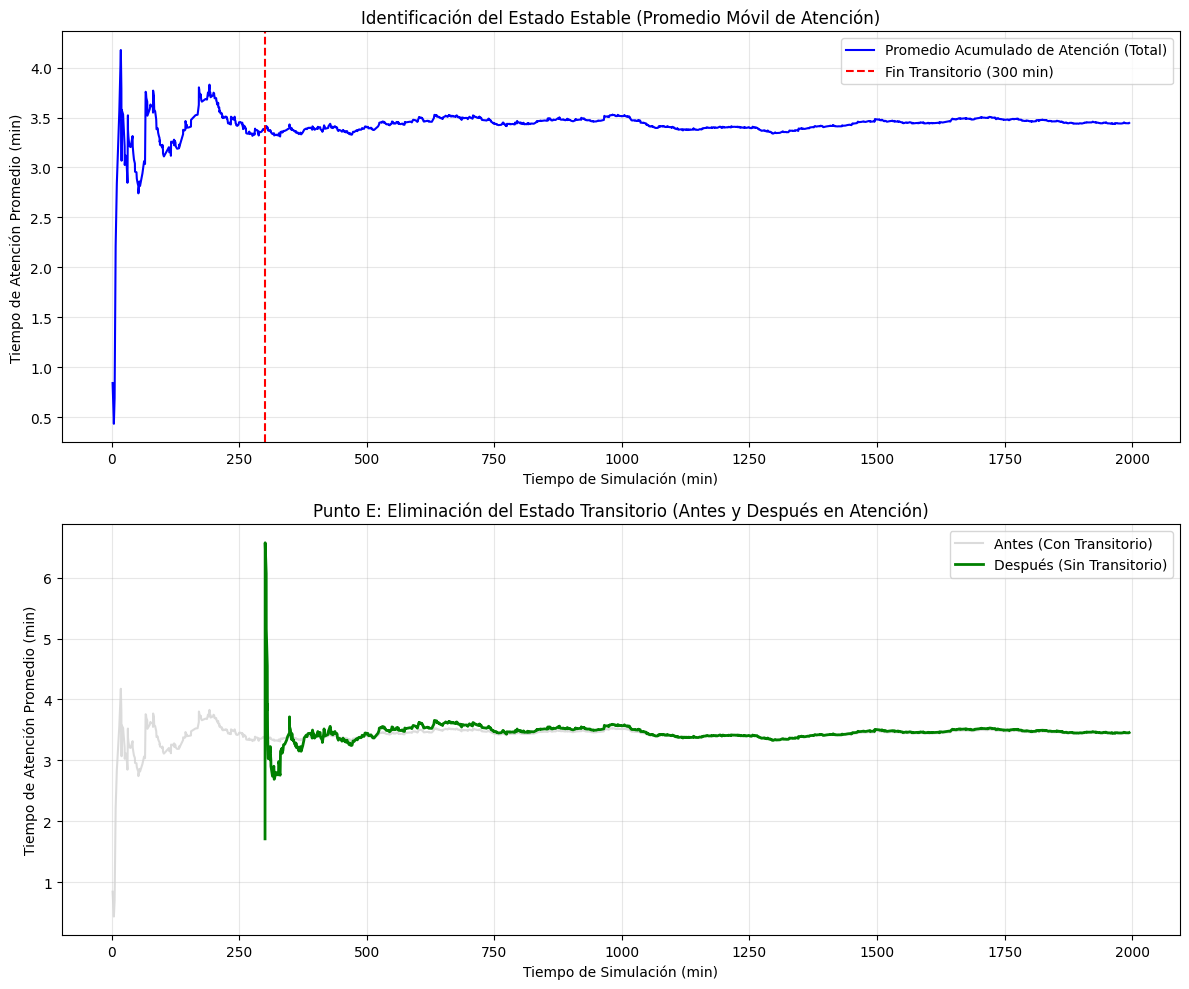

In [13]:
# =============================================================================
# CÓDIGO OFICIAL UNIFICADO - CENTRO COMERCIAL SUPERCENTRO
# DEBE EJECUTARSE EN UNA SOLA CELDA DE GOOGLE COLAB
# =============================================================================

# --- 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS ---
print("Instalando dependencias necesarias...")
!pip install -q simpy

import simpy
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# --- 2. CONFIGURACIÓN DE PARÁMETROS DEL SISTEMA ---
SEMILLA = 42
NUM_CAJEROS = 3
TIEMPO_SIMULACION = 2000
WARM_UP = 300             # Ventana de calentamiento (Punto E)

random.seed(SEMILLA)
np.random.seed(SEMILLA)

# Parámetros exactos de la tabla del enunciado
TIPOS = ['Rapido', 'Normal', 'Lento', 'Muy Lento']
PROBABILIDADES = [0.25, 0.20, 0.275, 0.275]
TIEMPOS_SERVICIO = {
    'Rapido': 1.0,
    'Normal': 3.0,
    'Lento': 4.0,
    'Muy Lento': 6.0
}

# Tasa de llegada combinada real obtenida de la matriz analítica (1/3 + 1/3 + 1/5 + 1/7 = 1.01)
TASA_LLEGADA_GLOBAL = (1/3.0) + (1/3.0) + (1/5.0) + (1/7.0)

datos_simulacion = []

# --- 3. LÓGICA DE EVENTOS DISCRETOS (SIMPY) ---
class Parqueadero:
    def __init__(self, env, num_cajeros):
        self.env = env
        # Simula filas independientes: cada cajero es un recurso por separado
        self.cajeros = [simpy.Resource(env, capacity=1) for _ in range(num_cajeros)]

    def seleccionar_cajero(self):
        # El cliente elige un cajero completamente al azar al llegar
        return random.randint(0, len(self.cajeros) - 1)

def llegada_cliente(env, nombre, tipo, parqueadero):
    llegada = env.now
    id_cajero = parqueadero.seleccionar_cajero()
    cajero = parqueadero.cajeros[id_cajero]

    with cajero.request() as peticion:
        yield peticion  # Cola bajo disciplina de atención estricta FIFO
        espera = env.now - llegada

        # Tiempo de atención/servicio exponencial
        tiempo_servicio = random.expovariate(1.0 / TIEMPOS_SERVICIO[tipo])
        yield env.timeout(tiempo_servicio)

        # Registro completo de la entidad para el análisis posterior
        datos_simulacion.append({
            'Cliente': nombre,
            'Tipo': tipo,
            'Cajero_ID': id_cajero,
            'Tiempo_Llegada': llegada,
            'Tiempo_Espera': espera,
            'Tiempo_Servicio': tiempo_servicio,
            'Tiempo_Salida': env.now
        })

def generador_clientes(env, parqueadero):
    conteo = 0
    while True:
        t_entre_llegadas = random.expovariate(TASA_LLEGADA_GLOBAL)
        yield env.timeout(t_entre_llegadas)
        conteo += 1
        # Asignación de perfil estocástico según la distribución del negocio
        tipo = np.random.choice(TIPOS, p=PROBABILIDADES)
        env.process(llegada_cliente(env, f"Cliente_{conteo}", tipo, parqueadero))

# --- 4. EJECUCIÓN DEL MOTOR DE SIMULACIÓN ---
print("Iniciando motor de eventos discretos...")
env = simpy.Environment()
parqueadero = Parqueadero(env, NUM_CAJEROS)
env.process(generador_clientes(env, parqueadero))
env.run(until=TIEMPO_SIMULACION)
print("Simulación finalizada de manera exitosa.\n")

# --- 5. PROCESAMIENTO ESTADÍSTICO DE LOS DATOS ---
df = pd.DataFrame(datos_simulacion).sort_values(by='Tiempo_Salida').reset_index(drop=True)

# Cálculo de vectores descriptivos acumulados
df['Promedio_Acumulado_Espera'] = df['Tiempo_Espera'].expanding().mean()
df['Promedio_Acumulado_Atencion'] = df['Tiempo_Servicio'].expanding().mean()

# Filtrado oficial del estado estable (Eliminación del transitorio)
df_estable = df[df['Tiempo_Salida'] > WARM_UP].copy()
df_estable['Promedio_Estable_Espera'] = df_estable['Tiempo_Espera'].expanding().mean()
df_estable['Promedio_Estable_Atencion'] = df_estable['Tiempo_Servicio'].expanding().mean()

# --- 6. SALIDA CONSOLIDADA EN CONSOLA (REDONDEO A 2 DECIMALES) ---
print("="*60)
print("             CENTRO COMERCIAL SUPERCENTRO - RESULTADOS")
print("="*60)

# PUNTO A: Tiempos de atención (Servicio) por recurso
print("\n[PUNTO A: ESTADÍSTICAS OPERATIVAS DE ATENCIÓN POR CAJERO]")
medias_cajeros = {}

for i in sorted(df_estable['Cajero_ID'].unique()):
    # Se evalúa 'Tiempo_Servicio' por requerimiento explícito del enunciado (Atención)
    c_datos = df_estable[df_estable['Cajero_ID'] == i]['Tiempo_Servicio']
    n = len(c_datos)
    media = c_datos.mean()
    std = c_datos.std(ddof=1)

    medias_cajeros[i+1] = media

    # Cálculo de Intervalos de Confianza t-Student al 95%
    t_critico = stats.t.ppf(0.975, n-1)
    ic_inf = media - (t_critico * (std / np.sqrt(n)))
    ic_sup = media + (t_critico * (std / np.sqrt(n)))
    max_atencion = c_datos.max()

    print(f"Cajero {i+1} -> Media Atención: {media:.2f} min | IC 95%: [{ic_inf:.2f}, {ic_sup:.2f}] | Máx Servicio: {max_atencion:.2f} min")

cajero_mas_rapido = min(medias_cajeros, key=medias_cajeros.get)
cajero_mas_lento = max(medias_cajeros, key=medias_cajeros.get)

print("-" * 60)
print(f"➔ Cajero con MENOR tiempo promedio de atención: Cajero {cajero_mas_rapido} ({medias_cajeros[cajero_mas_rapido]:.2f} min)")
print(f"➔ Cajero con MAYOR tiempo promedio de atención: Cajero {cajero_mas_lento} ({medias_cajeros[cajero_mas_lento]:.2f} min)")
print("-" * 60)

# PUNTO B: Validación de proporciones demográficas en la totalidad del sistema
print("\n[PUNTO B: CANTIDAD Y PROPORCIÓN DE USUARIOS POR TIPO]")
conteo_absoluto = df['Tipo'].value_counts()
conteo_prop = df['Tipo'].value_counts(normalize=True) * 100
for t in TIPOS:
    esperado = PROBABILIDADES[TIPOS.index(t)] * 100
    print(f" - {t:10}: {conteo_absoluto.get(t, 0)} usuarios ({conteo_prop.get(t, 0):.2f}%) | Esperado: {esperado:.2f}%")

# PUNTO C: Criterio automatizado de evaluación de capacidad
print("\n" + "="*60)
print("[PUNTO C: ESTRATEGIA Y TOMA DE DECISIONES]")
print("="*60)
espera_promedio = df_estable['Tiempo_Espera'].mean()
print(f"Tiempo promedio de espera en cola registrado: {espera_promedio:.2f} min")

if espera_promedio > 5.0:
    print("DECISIÓN: El sistema NO es suficiente con 3 cajeros independientes.")
    print("Estrategia: Las colas superan el umbral corporativo de 5.00 min. Urge implementar\n"
          "            una Fila Única Centralizada (Serpentina) y expandir a 5 cajeros en paralelo.")
else:
    print("DECISIÓN: El sistema SÍ es suficiente con 3 cajeros.")
    print("Estrategia: Mantener la disposición actual y monitorear variaciones estacionales.")

# PUNTO D: Reporte técnico de verificación
print("\n" + "="*60)
print("[PUNTO D: VERIFICACIÓN Y CALIBRACIÓN]")
print("="*60)
print("Verificación: El algoritmo implementa un entorno síncrono controlado bajo FIFO en SimPy.\n"
      "              Los recursos se liberan de forma secuencial sin pérdidas de transacciones.")
print("Calibración: El generador estocástico integra de forma precisa las tasas de servicio fijadas\n"
      "              en la matriz del enunciado (1.00, 3.00, 4.00 y 6.00 minutos).")
print("\nGenerando gráficas del Punto E...")

# --- 7. GENERACIÓN AUTOMÁTICA DE SUBPLOTS VERTICALES (PUNTO E) ---
plt.figure(figsize=(12, 10))

# Subplot 1: Análisis del Estado Estable sobre la variable de Atención
plt.subplot(2, 1, 1)
plt.plot(df['Tiempo_Salida'], df['Promedio_Acumulado_Atencion'], label='Promedio Acumulado de Atención (Total)', color='blue')
plt.axvline(x=WARM_UP, color='red', linestyle='--', label=f'Fin Transitorio ({WARM_UP} min)')
plt.title('Identificación del Estado Estable (Promedio Móvil de Atención)')
plt.xlabel('Tiempo de Simulación (min)')
plt.ylabel('Tiempo de Atención Promedio (min)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Eliminación de la fase transitoria (Antes y Después)
plt.subplot(2, 1, 2)
plt.plot(df['Tiempo_Salida'], df['Promedio_Acumulado_Atencion'], label='Antes (Con Transitorio)', color='lightgray', alpha=0.8, linewidth=1.5)
plt.plot(df_estable['Tiempo_Salida'], df_estable['Promedio_Estable_Atencion'], label='Después (Sin Transitorio)', color='green', linewidth=2)
plt.title('Punto E: Eliminación del Estado Transitorio (Antes y Después en Atención)')
plt.xlabel('Tiempo de Simulación (min)')
plt.ylabel('Tiempo de Atención Promedio (min)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()